# FastKAN-AD + DeepSVDD Hybrid on MSL with Alpha Tuning and EasyTSAD Evaluation

This notebook rebuilds the holdout-tuned hybrid model using an **RBF / FastKAN-style KAN-AD backbone** instead of the original Fourier KAN-AD backbone.

## What stays the same
- MSL **holdout** setup:
  - original MSL **train** stays as train
  - the **first anomalous part of the original test** is used as a **calibration split** for alpha tuning
  - the **remaining test tail** becomes the final EasyTSAD test set
- Final anomaly score:

\[
s_t = \alpha \cdot \sigma(z(E_t)) + (1-\alpha) \cdot \sigma(z(D_t))
\]

where:
- \(E_t\): prediction error
- \(D_t\): DeepSVDD distance
- \(z(\cdot)\): z-score using **train-only** statistics
- \(\sigma\): sigmoid

## What changes
- The KAN-AD forecasting branch now uses an **RBF family function** (FastKAN-style) instead of the original Fourier family.

## Final workflow
1. Install repos and EasyTSAD
2. Build a custom MSL holdout dataset on disk
3. Train the FastKAN-AD + DeepSVDD hybrid model
4. Tune **alpha** on the calibration split
5. Run final evaluation on the holdout test split with EasyTSAD


In [1]:

# Cell 1 — Install dependencies and clone repositories

!pip install --upgrade pip
!pip install torch torchinfo tqdm numpy scikit-learn matplotlib pandas toml

!rm -rf /content/KAN-AD
!rm -rf /content/datasets

!git clone https://github.com/CSTCloudOps/KAN-AD.git /content/KAN-AD
!git clone https://github.com/CSTCloudOps/datasets.git /content/datasets

!rm -rf /content/KAN-AD/datasets
!mv /content/datasets /content/KAN-AD/datasets

%cd /content/KAN-AD

Cloning into '/content/KAN-AD'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 18 (delta 1), reused 15 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 61.77 KiB | 988.00 KiB/s, done.
Resolving deltas: 100% (1/1), done.
Cloning into '/content/datasets'...
remote: Enumerating objects: 4503, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 4503 (delta 2), reused 0 (delta 0), pack-reused 4496 (from 3)
Receiving objects: 100% (4503/4503), 262.52 MiB | 19.79 MiB/s, done.
Resolving deltas: 100% (1962/1962), done.
Updating files: 100% (5564/5564), done.
/content/KAN-AD


In [2]:

# Cell 2 — Install EasyTSAD, fix import syntax issue, and configure paths

!pip install git+https://github.com/CSTCloudOps/EasyTSAD.git
!sed -i 's/TSData,*/TSData/g' /usr/local/lib/python3.*/dist-packages/EasyTSAD/DataFactory/__init__.py || true
!grep -n "TSData" /usr/local/lib/python3.*/dist-packages/EasyTSAD/DataFactory/__init__.py | head -n 20

import os
import sys
import glob

REPO_ROOT = "/content/KAN-AD"
DATA_ROOT = "/content/KAN-AD/datasets"

sys.path.insert(0, REPO_ROOT)

candidates = glob.glob("/content/KAN-AD/**/kanad/kanad.py", recursive=True)
print("Found KAN-AD candidates:", candidates)
assert candidates, "Could not find kanad/kanad.py inside the cloned KAN-AD repo."

KANAD_PY = sorted(candidates, key=len)[0]
KANAD_PKG_DIR = os.path.dirname(KANAD_PY)
KANAD_ROOT_DIR = os.path.dirname(KANAD_PKG_DIR)

sys.path.insert(0, KANAD_ROOT_DIR)

print("KANAD_PKG_DIR =", KANAD_PKG_DIR)
print("KANAD_ROOT_DIR =", KANAD_ROOT_DIR)
print("sys.path[:4] =", sys.path[:4])

  Cloning https://github.com/CSTCloudOps/EasyTSAD.git to /tmp/pip-req-build-8ld1xa6a
  Running command git clone --filter=blob:none --quiet https://github.com/CSTCloudOps/EasyTSAD.git /tmp/pip-req-build-8ld1xa6a
  Resolved https://github.com/CSTCloudOps/EasyTSAD.git to commit 10f5e7a4b27f4a326961bb8a77176aac7f6d7cc1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
1:from .TSData import TSData
2:from .MTSData import MTSData
Found KAN-AD candidates: ['/content/KAN-AD/kanad/kanad.py']
KANAD_PKG_DIR = /content/KAN-AD/kanad
KANAD_ROOT_DIR = /content/KAN-AD
sys.path[:4] = ['/content/KAN-AD', '/content/KAN-AD', '/content', '/env/python']


In [3]:

# Cell 3 — Imports and sanity check

import json
import math
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import tqdm

from torch.utils.data import Dataset, DataLoader

from EasyTSAD.Controller import TSADController
from EasyTSAD.DataFactory import TSData
from EasyTSAD.Methods import BaseMethod
from EasyTSAD.Evaluations.Protocols import (
    EventF1PA,
    PointF1PA,
    PointKthF1PA,
    PointAuprcPA,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("TSADController imported:", TSADController)


Device: cuda
TSADController imported: <class 'EasyTSAD.Controller.TSADController.TSADController'>


In [4]:

# Cell 4 — Define the FastKAN-style RBF KAN-AD backbone helpers + sensor attention

class PeriodicIndexBasisLayer(nn.Module):
    """
    Index-based periodic basis retained from the KAN-AD family:
        sin(2*pi*n*i/T), cos(2*pi*n*i/T)
    """

    def __init__(self, order: int, window: int):
        super().__init__()
        self.order = int(order)
        self.window = int(window)
        idx = torch.arange(self.window, dtype=torch.float32)
        self.register_buffer("idx", idx)

    def forward(self, x):
        B, W = x.shape
        feats = []
        t = self.idx.to(x.device)
        for n in range(1, self.order + 1):
            feats.append(torch.sin(2.0 * math.pi * n * t / self.window).view(1, 1, W).repeat(B, 1, 1))
            feats.append(torch.cos(2.0 * math.pi * n * t / self.window).view(1, 1, W).repeat(B, 1, 1))
        return torch.cat(feats, dim=1) if feats else torch.empty(B, 0, W, device=x.device)


class GaussianRBFLayer(nn.Module):
    """
    Gaussian radial basis family (FastKAN-style).
    """

    def __init__(self, num_centers: int, sigma: float = 1.0):
        super().__init__()
        self.num_centers = int(num_centers)
        self.sigma = float(sigma)
        centers = torch.linspace(-1, 1, self.num_centers)
        self.register_buffer("centers", centers)

    def forward(self, x):
        x = x.unsqueeze(1)
        c = self.centers.view(1, -1, 1)
        return torch.exp(-((x - c) ** 2) / (self.sigma ** 2 + 1e-8))


class FastKANADModel(nn.Module):
    """
    FastKAN-style KAN-AD backbone.

    Mapping channels:
      - RBF family basis channels
      - periodic index basis channels
      - raw input channel

    Reducing:
      - Conv1d + BN + GELU
      - Conv1d + residual + BN + GELU
      - 1x1 projection + residual + BN + GELU

    Projection:
      - final temporal Conv1d over the full window
    """

    def __init__(
        self,
        window: int,
        order: int = 2,
        family_channels: int = None,
        sigma: float = 0.75,
    ):
        super().__init__()

        self.window = int(window)
        self.order = int(order)

        if family_channels is None:
            family_channels = 4
        self.family_channels = int(family_channels)

        self.family_layer = GaussianRBFLayer(num_centers=self.family_channels, sigma=sigma)
        self.family_out_channels = self.family_channels

        self.periodic_layer = PeriodicIndexBasisLayer(order=self.order, window=self.window)
        self.periodic_out_channels = 2 * self.order

        self.channels = self.family_out_channels + self.periodic_out_channels + 1

        self.init_conv = nn.Conv1d(self.channels, self.channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.inner_conv = nn.Conv1d(self.channels, self.channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.out_conv = nn.Conv1d(self.channels, 1, kernel_size=1, bias=False)
        self.final_conv = nn.Conv1d(1, 1, kernel_size=self.window, stride=1, padding=0, bias=True)

        self.bn1 = nn.BatchNorm1d(self.channels)
        self.bn2 = nn.BatchNorm1d(self.channels)
        self.bn3 = nn.BatchNorm1d(1)
        self.act = nn.GELU()

    def forward_feature(self, x: torch.Tensor):
        raw = x.unsqueeze(1)
        family = self.family_layer(x)
        periodic = self.periodic_layer(x)

        ff = torch.cat([family, periodic, raw], dim=1)
        res0 = raw
        res1 = ff

        ff = self.act(self.bn1(self.init_conv(ff)))
        ff = self.act(self.bn2(self.inner_conv(ff) + res1))
        ff = self.act(self.bn3(self.out_conv(ff) + res0))
        return ff

    def forward_head(self, ff: torch.Tensor):
        return self.final_conv(ff).squeeze(1)

    def forward(self, x: torch.Tensor):
        ff = self.forward_feature(x)
        return self.forward_head(ff)


class SensorSelfAttention(nn.Module):
    """
    Self-attention across sensors at each time step.
    Input: x of shape (B, T, F)
    Output: mixed x of shape (B, T, F)
    """
    def __init__(self, n_features: int, d_model: int = 16, n_heads: int = 2, dropout: float = 0.0):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.n_features = int(n_features)
        self.embed = nn.Linear(1, d_model)
        self.mha = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.out = nn.Linear(d_model, 1)

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        B, T, F = x.shape
        if F != self.n_features:
            raise ValueError(f"Expected F={self.n_features} features, got {F}")

        xt = x.reshape(B * T, F, 1)
        z = self.embed(xt)

        if return_attn:
            z_attn, attn = self.mha(z, z, z, need_weights=True, average_attn_weights=True)
            attn_avg = attn.mean(dim=0)  # (F, F)
        else:
            z_attn, _ = self.mha(z, z, z, need_weights=False)
            attn_avg = None

        y = self.out(z_attn).squeeze(-1)
        x_mix = y.reshape(B, T, F)
        return x_mix, attn_avg


print("FastKANADModel + SensorSelfAttention ready.")


FastKANADModel + SensorSelfAttention ready.


In [5]:
# Cell 5 — Build MSL holdout dataset + save calibration arrays outside EasyTSAD tree

import os
import shutil
import numpy as np

# -----------------------------
# Basic paths / names
# -----------------------------
ROOT_DIR = "/content/KAN-AD"
DATA_ROOT = os.path.join(ROOT_DIR, "datasets", "MTS")
ORIG_DATASET = "MSL"
CUSTOM_DATASET = "MSL_HybridHoldout"

orig_curve_dir = os.path.join(DATA_ROOT, ORIG_DATASET, "AllInOne")
custom_dataset_dir = os.path.join(DATA_ROOT, CUSTOM_DATASET)
custom_curve_dir = os.path.join(custom_dataset_dir, "AllInOne")

print("Original MSL curve dir:", orig_curve_dir)

# -----------------------------
# Load original MSL arrays
# -----------------------------
train = np.load(os.path.join(orig_curve_dir, "train.npy"))
test = np.load(os.path.join(orig_curve_dir, "test.npy"))

train_label_path = os.path.join(orig_curve_dir, "train_label.npy")
test_label_path = os.path.join(orig_curve_dir, "test_label.npy")

if os.path.exists(train_label_path):
    train_label = np.load(train_label_path)
else:
    train_label = np.zeros(len(train), dtype=np.int64)

if os.path.exists(test_label_path):
    test_label = np.load(test_label_path)
else:
    raise FileNotFoundError(f"Missing test labels: {test_label_path}")

print("train shape:", train.shape)
print("test shape :", test.shape)
print("train_label shape:", train_label.shape, " positives:", int(train_label.sum()))
print("test_label shape :", test_label.shape, " positives:", int(test_label.sum()))

# -----------------------------
# Choose calibration split from the beginning of labeled test
# Goal: have a labeled calibration set with anomalies for alpha tuning
# -----------------------------
test_len = len(test)
default_calib_end = int(0.20 * test_len)  # first 20% of test

# Ensure calibration contains anomalies; if not, extend until it does
positive_idx = np.where(test_label > 0)[0]
if len(positive_idx) == 0:
    raise ValueError("MSL test labels contain no anomalies; cannot build calibration split.")

first_pos = int(positive_idx[0])
last_pos = int(positive_idx[min(len(positive_idx) - 1, max(0, int(0.10 * len(positive_idx))))])

calib_end = max(default_calib_end, last_pos + 1)
calib_end = min(calib_end, test_len - 1)

calib_arr = test[:calib_end].copy()
calib_label = test_label[:calib_end].copy()

final_test = test[calib_end:].copy()
final_test_label = test_label[calib_end:].copy()

print("\nChosen calibration end index:", calib_end)
print("Calibration shape:", calib_arr.shape, " positives:", int(calib_label.sum()))
print("Final test shape :", final_test.shape, " positives:", int(final_test_label.sum()))

if calib_label.sum() == 0:
    raise ValueError("Calibration split still has no anomalies. Increase calibration size.")

# -----------------------------
# Remove old broken dataset tree if it exists
# -----------------------------
if os.path.exists(custom_dataset_dir):
    shutil.rmtree(custom_dataset_dir)

os.makedirs(custom_curve_dir, exist_ok=True)

# Save EasyTSAD dataset files
np.save(os.path.join(custom_curve_dir, "train.npy"), train)
np.save(os.path.join(custom_curve_dir, "train_label.npy"), train_label)
np.save(os.path.join(custom_curve_dir, "test.npy"), final_test)
np.save(os.path.join(custom_curve_dir, "test_label.npy"), final_test_label)

# Optional metadata copy if original files exist
for extra_name in ["info.json", "meta.json"]:
    src = os.path.join(orig_curve_dir, extra_name)
    dst = os.path.join(custom_curve_dir, extra_name)
    if os.path.exists(src):
        shutil.copy2(src, dst)

# -----------------------------
# Save calibration arrays OUTSIDE EasyTSAD dataset tree
# -----------------------------
RUNTIME_DIR = os.path.join(ROOT_DIR, "kanad_runtime")
os.makedirs(RUNTIME_DIR, exist_ok=True)

CALIB_DIR = os.path.join(RUNTIME_DIR, f"{CUSTOM_DATASET}_calibration")
if os.path.exists(CALIB_DIR):
    shutil.rmtree(CALIB_DIR)
os.makedirs(CALIB_DIR, exist_ok=True)

np.save(os.path.join(CALIB_DIR, "calib.npy"), calib_arr)
np.save(os.path.join(CALIB_DIR, "calib_label.npy"), calib_label)

# -----------------------------
# Sanity checks
# -----------------------------
print("\nCreated EasyTSAD dataset at:", custom_curve_dir)
print("Saved files:", sorted(os.listdir(custom_curve_dir)))

print("\nCalibration dir:", CALIB_DIR)
print("Calibration files:", sorted(os.listdir(CALIB_DIR)))

assert os.path.exists(os.path.join(custom_curve_dir, "train.npy"))
assert os.path.exists(os.path.join(custom_curve_dir, "test.npy"))
assert os.path.exists(os.path.join(custom_curve_dir, "test_label.npy"))
assert os.path.exists(os.path.join(CALIB_DIR, "calib.npy"))
assert os.path.exists(os.path.join(CALIB_DIR, "calib_label.npy"))

print("\nCell 5 completed successfully.")

Original MSL curve dir: /content/KAN-AD/datasets/MTS/MSL/AllInOne
train shape: (58317, 55)
test shape : (73729, 55)
train_label shape: (58317,)  positives: 0
test_label shape : (73729,)  positives: 7766

Chosen calibration end index: 14745
Calibration shape: (14745, 55)  positives: 2034
Final test shape : (58984, 55)  positives: 5732

Created EasyTSAD dataset at: /content/KAN-AD/datasets/MTS/MSL_HybridHoldout/AllInOne
Saved files: ['info.json', 'test.npy', 'test_label.npy', 'train.npy', 'train_label.npy']

Calibration dir: /content/KAN-AD/kanad_runtime/MSL_HybridHoldout_calibration
Calibration files: ['calib.npy', 'calib_label.npy']

Cell 5 completed successfully.


In [6]:

# Cell 6 — Utility functions: segmentation, calibration F1 search, normalization, plotting

def contiguous_segments(binary_labels: np.ndarray):
    y = np.asarray(binary_labels).astype(int)
    segs = []
    start = None
    for i, v in enumerate(y):
        if v == 1 and start is None:
            start = i
        elif v == 0 and start is not None:
            segs.append((start, i - 1))
            start = None
    if start is not None:
        segs.append((start, len(y) - 1))
    return segs


def segment_overlap(a, b):
    return not (a[1] < b[0] or b[1] < a[0])


def event_f1_from_binary(pred_binary: np.ndarray, true_binary: np.ndarray):
    gt_segs = contiguous_segments(true_binary)
    pr_segs = contiguous_segments(pred_binary)

    if len(gt_segs) == 0 and len(pr_segs) == 0:
        return 1.0, 1.0, 1.0
    if len(gt_segs) == 0:
        return 0.0, 0.0, 0.0
    if len(pr_segs) == 0:
        return 0.0, 0.0, 0.0

    used_pr = set()
    tp = 0
    for gt in gt_segs:
        for j, pr in enumerate(pr_segs):
            if j in used_pr:
                continue
            if segment_overlap(gt, pr):
                tp += 1
                used_pr.add(j)
                break

    precision = tp / max(len(pr_segs), 1)
    recall = tp / max(len(gt_segs), 1)
    f1 = 0.0 if (precision + recall == 0) else 2 * precision * recall / (precision + recall)
    return f1, precision, recall


def best_event_f1_threshold(scores: np.ndarray, labels: np.ndarray, n_grid: int = 200):
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels).astype(int)

    if labels.sum() == 0:
        return 0.0, float(np.max(scores)), 0.0, 0.0

    lo = float(np.min(scores))
    hi = float(np.max(scores))

    if not np.isfinite(lo) or not np.isfinite(hi):
        raise ValueError("Non-finite scores encountered during threshold search.")

    if hi <= lo:
        pred = (scores > lo).astype(int)
        f1, p, r = event_f1_from_binary(pred, labels)
        return f1, lo, p, r

    thresholds = np.linspace(lo, hi, n_grid)
    best = (-1.0, lo, 0.0, 0.0)

    for thr in thresholds:
        pred = (scores > thr).astype(int)
        f1, p, r = event_f1_from_binary(pred, labels)
        if f1 > best[0]:
            best = (f1, float(thr), float(p), float(r))

    return best


def sigmoid_np(x):
    x = np.clip(x, -8.0, 8.0)
    return 1.0 / (1.0 + np.exp(-x))


def zscore_sigmoid(x, mu, std, eps=1e-8):
    z = (x - mu) / (std + eps)
    return sigmoid_np(z)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def show_overlay(scores, labels, title, max_points=4000):
    n = min(len(scores), max_points)
    x = np.arange(n)
    plt.figure(figsize=(14, 4))
    plt.plot(x, scores[:n], label="score")
    if labels is not None and n > 0:
        ymax = max(1e-6, float(np.max(scores[:n])))
        plt.fill_between(x, 0, ymax, where=labels[:n].astype(bool), alpha=0.2, step="pre", label="anomaly")
    plt.title(title)
    plt.legend()
    plt.show()

In [7]:

# Cell 7 — Window datasets for train/valid/test and calibration

class MTSWindowDataset(Dataset):
    def __init__(self, tsData, phase, window_size):
        self.window_size = int(window_size)

        if phase == "train":
            self.data = np.asarray(tsData.train)
        elif phase == "valid":
            self.data = np.asarray(tsData.valid)
        elif phase == "test":
            self.data = np.asarray(tsData.test)
        else:
            raise ValueError("phase must be train / valid / test")

        assert self.data.ndim == 2, f"Expected 2D MTS array, got {self.data.shape}"
        self.N, self.F = self.data.shape
        self.sample_num = max(self.N - self.window_size, 0)

    def __len__(self):
        return self.sample_num

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


class ArrayWindowDataset(Dataset):
    def __init__(self, data: np.ndarray, labels: np.ndarray, window_size: int):
        self.data = np.asarray(data)
        self.labels = np.asarray(labels).astype(int)
        self.window_size = int(window_size)

        assert self.data.ndim == 2, f"Expected 2D array, got {self.data.shape}"
        assert len(self.data) == len(self.labels), "Data/label length mismatch"

        self.N, self.F = self.data.shape
        self.sample_num = max(self.N - self.window_size, 0)

    def __len__(self):
        return self.sample_num

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size]
        label = self.labels[idx + self.window_size]
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(label, dtype=torch.long),
        )

print("Datasets ready.")

Datasets ready.


In [8]:

# Cell 8 — Define the attention-enhanced hybrid model with alpha tuning on calibration data

class Attn_FastKANAD_SVDD_AlphaTuned_Holdout(BaseMethod):
    def __init__(self, params: dict) -> None:
        super().__init__()

        self.__anomaly_score = None

        self.batch_size = int(params["batch_size"])
        self.window = int(params["window"])
        self.order = int(params["order"])
        self.epochs = int(params["epochs"])
        self.lr = float(params["lr"])

        self.lambda_svdd = float(params.get("lambda_svdd", 0.1))
        self.emb_dim = int(params.get("emb_dim", 64))
        self.patience = int(params.get("patience", 6))

        self.alpha_grid = params.get("alpha_grid", [round(x, 2) for x in np.linspace(0, 1, 11)])
        self.calib_data_path = params["calib_data_path"]
        self.calib_label_path = params["calib_label_path"]

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.family_channels = int(params.get("family_channels", 4))
        self.sigma = float(params.get("sigma", 0.75))

        self.n_features = int(params.get("n_features", 51))
        self.attn_d_model = int(params.get("attn_d_model", 16))
        self.attn_heads = int(params.get("attn_heads", 2))
        self.attn_dropout = float(params.get("attn_dropout", 0.0))

        self.model = FastKANADModel(
            window=self.window,
            order=self.order,
            family_channels=self.family_channels,
            sigma=self.sigma,
        ).to(self.device)

        self.sensor_attn = SensorSelfAttention(
            n_features=self.n_features,
            d_model=self.attn_d_model,
            n_heads=self.attn_heads,
            dropout=self.attn_dropout,
        ).to(self.device)

        self.embed_head = nn.Sequential(
            nn.Linear(self.window, 128),
            nn.GELU(),
            nn.Linear(128, self.emb_dim),
        ).to(self.device)

        self.optimizer = optim.Adam(
            list(self.model.parameters()) +
            list(self.sensor_attn.parameters()) +
            list(self.embed_head.parameters()),
            lr=self.lr
        )
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=5, gamma=0.75)
        self.mse_loss = nn.MSELoss()

        self.center = None
        self.last_attn_matrix = None

        self.pred_mu = None
        self.pred_std = None
        self.svdd_mu = None
        self.svdd_std = None

        self.alpha = 0.5
        self.best_calib_event_f1 = None
        self.best_calib_threshold = None
        self.calib_tuning_table = None

        self.best_state = None

    def _compute_embedding(self, ff):
        feat = ff.squeeze(1)
        return self.embed_head(feat)

    def _mix_sensors(self, x, return_attn: bool = False):
        x_mix, attn_avg = self.sensor_attn(x, return_attn=return_attn)
        if attn_avg is not None:
            self.last_attn_matrix = attn_avg.detach().cpu()
        return x_mix

    def _forward_batch(self, x, target):
        B, W, F = x.shape

        x_mix = self._mix_sensors(x, return_attn=False)
        x_1d = x_mix.permute(0, 2, 1).reshape(B * F, W)
        t_1d = target.reshape(B * F, 1)

        ff = self.model.forward_feature(x_1d)
        out = self.model.forward_head(ff).reshape(B * F, 1)

        pred_loss = self.mse_loss(out, t_1d)
        pred_err = (out - t_1d).abs().reshape(B, F).max(dim=1).values

        z = self._compute_embedding(ff).reshape(B, F, -1).mean(dim=1)
        svdd_dist = ((z - self.center) ** 2).sum(dim=1)
        svdd_loss = svdd_dist.mean()

        return pred_err, svdd_dist, pred_loss, svdd_loss

    def _compute_center(self, train_loader):
        zs = []
        self.model.eval()
        self.sensor_attn.eval()
        self.embed_head.eval()

        with torch.no_grad():
            for x, y in tqdm.tqdm(train_loader, desc="Compute SVDD center"):
                x = x.to(self.device)
                y = y.to(self.device)

                B, W, F = x.shape
                x_mix = self._mix_sensors(x, return_attn=False)
                x_1d = x_mix.permute(0, 2, 1).reshape(B * F, W)

                ff = self.model.forward_feature(x_1d)
                z = self._compute_embedding(ff).reshape(B, F, -1).mean(dim=1)
                zs.append(z.detach().cpu())

        Z = torch.cat(zs, dim=0)
        c = Z.mean(dim=0).to(self.device)
        c[(c.abs() < 1e-6)] = 1e-6
        self.center = c

    def _collect_components_from_loader(self, loader, has_labels=False):
        pred_all = []
        svdd_all = []
        label_all = []

        self.model.eval()
        self.sensor_attn.eval()
        self.embed_head.eval()

        with torch.no_grad():
            if has_labels:
                iterator = loader
            else:
                iterator = ((x, y, None) for x, y in loader)

            for x, y, lab in iterator:
                x = x.to(self.device)
                y = y.to(self.device)

                pred_err, svdd_dist, _, _ = self._forward_batch(x, y)

                pred_all.append(pred_err.detach().cpu().numpy())
                svdd_all.append(svdd_dist.detach().cpu().numpy())

                if lab is not None:
                    label_all.append(lab.detach().cpu().numpy())

        pred_all = np.concatenate(pred_all) if pred_all else np.array([], dtype=float)
        svdd_all = np.concatenate(svdd_all) if svdd_all else np.array([], dtype=float)

        if has_labels:
            label_all = np.concatenate(label_all) if label_all else np.array([], dtype=int)
            return pred_all, svdd_all, label_all

        return pred_all, svdd_all

    def _fit_normalization_stats(self, train_loader):
        pred_train, svdd_train = self._collect_components_from_loader(train_loader, has_labels=False)

        self.pred_mu = float(pred_train.mean())
        self.pred_std = float(pred_train.std() + 1e-8)
        self.svdd_mu = float(svdd_train.mean())
        self.svdd_std = float(svdd_train.std() + 1e-8)

        print("\nNormalization statistics (train only)")
        print(f"pred_mu={self.pred_mu:.6f}, pred_std={self.pred_std:.6f}")
        print(f"svdd_mu={self.svdd_mu:.6f}, svdd_std={self.svdd_std:.6f}")

    def _tune_alpha_on_calibration(self):
        calib_data = np.load(self.calib_data_path)
        calib_label = np.load(self.calib_label_path)

        calib_loader = DataLoader(
            ArrayWindowDataset(calib_data, calib_label, self.window),
            batch_size=self.batch_size,
            shuffle=False
        )

        pred_c, svdd_c, labels_c = self._collect_components_from_loader(calib_loader, has_labels=True)

        pred_c_n = zscore_sigmoid(pred_c, self.pred_mu, self.pred_std)
        svdd_c_n = zscore_sigmoid(svdd_c, self.svdd_mu, self.svdd_std)

        print("\nAlpha tuning on calibration split")
        best = (-1.0, None, None, None, None)
        rows = []

        for alpha in self.alpha_grid:
            fused = alpha * pred_c_n + (1.0 - alpha) * svdd_c_n
            best_f1, best_thr, best_p, best_r = best_event_f1_threshold(fused, labels_c, n_grid=200)

            rows.append({
                "alpha": float(alpha),
                "event_f1": float(best_f1),
                "precision": float(best_p),
                "recall": float(best_r),
                "threshold": float(best_thr),
            })

            print(f"alpha={alpha:.2f} | calib_event_f1={best_f1:.6f} | threshold={best_thr:.6f}")

            if best_f1 > best[0]:
                best = (best_f1, alpha, best_thr, labels_c, fused)

        self.best_calib_event_f1 = float(best[0])
        self.alpha = float(best[1])
        self.best_calib_threshold = float(best[2])
        self.calib_tuning_table = pd.DataFrame(rows)

        print(f"\nSelected alpha={self.alpha:.2f} with calib_event_f1={self.best_calib_event_f1:.6f}")
        print(f"Selected calibration threshold={self.best_calib_threshold:.6f}")

        show_overlay(best[4], best[3], f"Calibration fused score overlay (best alpha={self.alpha:.2f})")

    def train_valid_phase(self, tsTrain: TSData):
        train_loader = DataLoader(
            MTSWindowDataset(tsTrain, "train", self.window),
            batch_size=self.batch_size,
            shuffle=True
        )
        valid_loader = DataLoader(
            MTSWindowDataset(tsTrain, "valid", self.window),
            batch_size=self.batch_size,
            shuffle=False
        )

        self._compute_center(train_loader)

        best_valid = float("inf")
        patience_counter = 0

        for epoch in range(1, self.epochs + 1):
            self.model.train()
            self.sensor_attn.train()
            self.embed_head.train()

            train_losses = []
            train_pred_losses = []
            train_svdd_losses = []

            for x, y in tqdm.tqdm(train_loader, desc=f"Train {epoch}"):
                x = x.to(self.device)
                y = y.to(self.device)

                self.optimizer.zero_grad(set_to_none=True)

                pred_err, svdd_dist, pred_loss, svdd_loss = self._forward_batch(x, y)
                total_loss = pred_loss + self.lambda_svdd * svdd_loss

                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    list(self.model.parameters()) +
                    list(self.sensor_attn.parameters()) +
                    list(self.embed_head.parameters()),
                    max_norm=5.0
                )
                self.optimizer.step()

                train_losses.append(float(total_loss.item()))
                train_pred_losses.append(float(pred_loss.item()))
                train_svdd_losses.append(float(svdd_loss.item()))

            self.model.eval()
            self.sensor_attn.eval()
            self.embed_head.eval()

            valid_losses = []
            with torch.no_grad():
                for x, y in tqdm.tqdm(valid_loader, desc=f"Valid {epoch}"):
                    x = x.to(self.device)
                    y = y.to(self.device)

                    _, _, pred_loss, svdd_loss = self._forward_batch(x, y)
                    total_loss = pred_loss + self.lambda_svdd * svdd_loss
                    valid_losses.append(float(total_loss.item()))

            train_loss = float(np.mean(train_losses)) if train_losses else np.nan
            valid_loss = float(np.mean(valid_losses)) if valid_losses else np.nan

            print(
                f"Epoch {epoch} | "
                f"train_loss={train_loss:.6f} | "
                f"valid_loss={valid_loss:.6f} | "
                f"pred={np.mean(train_pred_losses):.6f} | "
                f"svdd={np.mean(train_svdd_losses):.6f}"
            )

            self.scheduler.step()

            if valid_loss < best_valid:
                best_valid = valid_loss
                patience_counter = 0
                self.best_state = {
                    "model": {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()},
                    "attn": {k: v.detach().cpu().clone() for k, v in self.sensor_attn.state_dict().items()},
                    "embed": {k: v.detach().cpu().clone() for k, v in self.embed_head.state_dict().items()},
                    "center": self.center.detach().cpu().clone(),
                }
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    print("Early stopping")
                    break

        assert self.best_state is not None, "No best model state was saved."
        self.model.load_state_dict(self.best_state["model"])
        self.sensor_attn.load_state_dict(self.best_state["attn"])
        self.embed_head.load_state_dict(self.best_state["embed"])
        self.center = self.best_state["center"].to(self.device)

        self._fit_normalization_stats(train_loader)
        self._tune_alpha_on_calibration()

    def test_phase(self, tsData: TSData):
        test_loader = DataLoader(
            MTSWindowDataset(tsData, "test", self.window),
            batch_size=self.batch_size,
            shuffle=False
        )

        pred_t, svdd_t = self._collect_components_from_loader(test_loader, has_labels=False)

        pred_t_n = zscore_sigmoid(pred_t, self.pred_mu, self.pred_std)
        svdd_t_n = zscore_sigmoid(svdd_t, self.svdd_mu, self.svdd_std)

        fused = self.alpha * pred_t_n + (1.0 - self.alpha) * svdd_t_n

        if len(fused) == 0:
            padded = np.zeros(len(tsData.test), dtype=float)
        else:
            prefix = np.full(self.window, fused[0], dtype=float)
            padded = np.concatenate([prefix, fused], axis=0)
            padded = padded[:len(tsData.test)]

        self.__anomaly_score = padded.astype(np.float64)

    def anomaly_score(self) -> np.ndarray:
        return self.__anomaly_score

    def param_statistic(self, save_file):
        stats = {
            "FastKAN_trainable_params": int(count_parameters(self.model)),
            "Attention_trainable_params": int(count_parameters(self.sensor_attn)),
            "SVDD_head_trainable_params": int(count_parameters(self.embed_head)),
            "total_trainable_params": int(
                count_parameters(self.model) +
                count_parameters(self.sensor_attn) +
                count_parameters(self.embed_head)
            ),
            "window": int(self.window),
            "family_channels": int(self.family_channels),
            "sigma": float(self.sigma),
            "order": int(self.order),
            "n_features": int(self.n_features),
            "attn_d_model": int(self.attn_d_model),
            "attn_heads": int(self.attn_heads),
            "attn_dropout": float(self.attn_dropout),
            "lambda_svdd": float(self.lambda_svdd),
            "emb_dim": int(self.emb_dim),
            "selected_alpha": float(self.alpha),
            "best_calib_event_f1": None if self.best_calib_event_f1 is None else float(self.best_calib_event_f1),
            "best_calib_threshold": None if self.best_calib_threshold is None else float(self.best_calib_threshold),
            "pred_mu": None if self.pred_mu is None else float(self.pred_mu),
            "pred_std": None if self.pred_std is None else float(self.pred_std),
            "svdd_mu": None if self.svdd_mu is None else float(self.svdd_mu),
            "svdd_std": None if self.svdd_std is None else float(self.svdd_std),
        }
        with open(save_file, "w") as f:
            json.dump(stats, f, indent=2)

print("Attention + FastKAN + DeepSVDD custom EasyTSAD method class is ready.")


Attention + FastKAN + DeepSVDD custom EasyTSAD method class is ready.


In [9]:

# Cell 9 — Create the config file for the updated hybrid model

alpha_grid = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

config_text = f"""\
[Data_Params]
preprocess = "z-score"
diff_order = 0

[Model_Params.Default]
window = 96
order = 2
family_channels = 4
sigma = 0.75
batch_size = 128
epochs = 60
lr = 0.001
lambda_svdd = 0.1
emb_dim = 64
patience = 6

n_features = 55
attn_d_model = 16
attn_heads = 2
attn_dropout = 0.0

# calibration arrays are intentionally stored outside the EasyTSAD dataset tree
calib_data_path = "{os.path.join(CALIB_DIR, 'calib.npy')}"
calib_label_path = "{os.path.join(CALIB_DIR, 'calib_label.npy')}"

alpha_grid = {alpha_grid}
"""

CFG_PATH = os.path.join(KANAD_PKG_DIR, "config_attn_fastkanad_svdd_alpha_holdout.toml")
with open(CFG_PATH, "w") as f:
    f.write(config_text)

print("Wrote config to:", CFG_PATH)
print(open(CFG_PATH).read())


Wrote config to: /content/KAN-AD/kanad/config_attn_fastkanad_svdd_alpha_holdout.toml
[Data_Params]
preprocess = "z-score"
diff_order = 0

[Model_Params.Default]
window = 96
order = 2
family_channels = 4
sigma = 0.75
batch_size = 128
epochs = 60
lr = 0.001
lambda_svdd = 0.1
emb_dim = 64
patience = 6

n_features = 55
attn_d_model = 16
attn_heads = 2
attn_dropout = 0.0

# calibration arrays are intentionally stored outside the EasyTSAD dataset tree
calib_data_path = "/content/KAN-AD/kanad_runtime/MSL_HybridHoldout_calibration/calib.npy"
calib_label_path = "/content/KAN-AD/kanad_runtime/MSL_HybridHoldout_calibration/calib_label.npy"

alpha_grid = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]



(2026-04-23 23:02:01,856) [INFO]: 
                         
███████╗ █████╗ ███████╗██╗   ██╗    ████████╗███████╗ █████╗ ██████╗ 
██╔════╝██╔══██╗██╔════╝╚██╗ ██╔╝    ╚══██╔══╝██╔════╝██╔══██╗██╔══██╗
█████╗  ███████║███████╗ ╚████╔╝        ██║   ███████╗███████║██║  ██║
██╔══╝  ██╔══██║╚════██║  ╚██╔╝         ██║   ╚════██║██╔══██║██║  ██║
███████╗██║  ██║███████║   ██║          ██║   ███████║██║  ██║██████╔╝
╚══════╝╚═╝  ╚═╝╚══════╝   ╚═╝          ╚═╝   ╚══════╝╚═╝  ╚═╝╚═════╝ 
                                                                      
                         
INFO:logger:
                         
███████╗ █████╗ ███████╗██╗   ██╗    ████████╗███████╗ █████╗ ██████╗ 
██╔════╝██╔══██╗██╔════╝╚██╗ ██╔╝    ╚══██╔══╝██╔════╝██╔══██╗██╔══██╗
█████╗  ███████║███████╗ ╚████╔╝        ██║   ███████╗███████║██║  ██║
██╔══╝  ██╔══██║╚════██║  ╚██╔╝         ██║   ╚════██║██╔══██║██║  ██║
███████╗██║  ██║███████║   ██║          ██║   ███████║██║  ██║██████╔╝
╚══════╝╚═╝  ╚═╝╚═════

Epoch 1 | train_loss=7695.295845 | valid_loss=7695.467300 | pred=7693.562768 | svdd=17.330668


Valid 2: 100%|██████████| 455/455 [00:08<00:00, 54.82it/s]


Epoch 2 | train_loss=7693.258021 | valid_loss=7693.105567 | pred=7693.052725 | svdd=2.052411


Valid 3: 100%|██████████| 455/455 [00:08<00:00, 52.74it/s]


...

Epoch 48 | train_loss=7691.008313 | valid_loss=7691.173625 | pred=7691.008264 | svdd=0.000545


Valid 49: 100%|██████████| 455/455 [00:07<00:00, 58.22it/s]


Epoch 49 | train_loss=7691.035729 | valid_loss=7691.309660 | pred=7691.035659 | svdd=0.000773


Valid 50: 100%|██████████| 455/455 [00:07<00:00, 57.81it/s]


Epoch 50 | train_loss=7691.037469 | valid_loss=7691.236653 | pred=7691.037422 | svdd=0.000528
Early stopping

Normalization statistics (train only)
pred_mu=34.097046, pred_std=649.552551
svdd_mu=0.000489, svdd_std=0.000827

Alpha tuning on calibration split
alpha=0.00 | calib_event_f1=0.000000 | threshold=0.999665
alpha=0.10 | calib_event_f1=0.500000 | threshold=0.948403
alpha=0.20 | calib_event_f1=0.500000 | threshold=0.897141
alpha=0.30 | calib_event_f1=0.500000 | threshold=0.845879
alpha=0.40 | calib_event_f1=0.500000 | threshold=0.794617
alpha=0.50 | calib_event_f1=0.500000 | threshold=0.743355
alpha=0.60 | calib_event_f1=0.500000 | threshold=0.692093
alpha=0.70 | calib_event_f1=0.500000 | threshold=0.640831
alpha=0.80 | calib_event_f1=0.500000 | threshold=0.589569
alpha=0.90 | calib_event_f1=0.500000 | threshold=0.538307
alpha=1.00 | calib_event_f1=0.500000 | threshold=0.487045

Selected alpha=0.10 with calib_event_f1=0.500000
Selected calibration threshold=0.948403


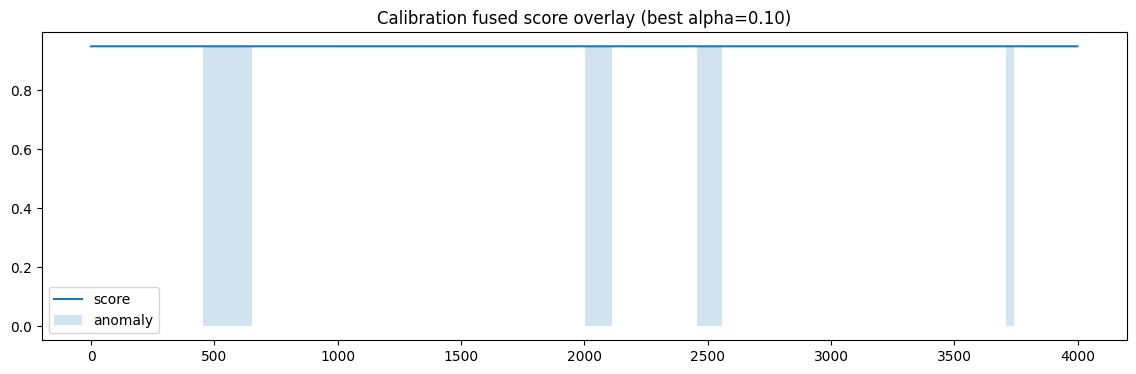

(2026-04-23 23:36:25,726) [INFO]: Register evaluations
INFO:logger:Register evaluations
(2026-04-23 23:36:25,727) [INFO]: Perform evaluations. Method[Attn_FastKANAD_SVDD_AlphaTuned_Holdout], Schema[naive].
INFO:logger:Perform evaluations. Method[Attn_FastKANAD_SVDD_AlphaTuned_Holdout], Schema[naive].
(2026-04-23 23:36:25,730) [INFO]:     [Load Data (All)] DataSets: MSL_HybridHoldout 
INFO:logger:    [Load Data (All)] DataSets: MSL_HybridHoldout 
(2026-04-23 23:36:25,756) [INFO]:     [Attn_FastKANAD_SVDD_AlphaTuned_Holdout] Eval dataset MSL_HybridHoldout <<<
INFO:logger:    [Attn_FastKANAD_SVDD_AlphaTuned_Holdout] Eval dataset MSL_HybridHoldout <<<
(2026-04-23 23:36:25,758) [INFO]:         [MSL_HybridHoldout] Using default margins (0, 5)
INFO:logger:        [MSL_HybridHoldout] Using default margins (0, 5)


In [10]:

# Cell 10 — Run the EasyTSAD experiment on the holdout dataset

gctrl = TSADController()

gctrl.set_dataset(
    dataset_type="MTS",
    dirname="/content/KAN-AD/datasets",
    datasets=[CUSTOM_DATASET],
)

METHOD_NAME = "Attn_FastKANAD_SVDD_AlphaTuned_Holdout"
TRAINING_SCHEMA = "naive"

gctrl.run_exps(
    method=METHOD_NAME,
    training_schema=TRAINING_SCHEMA,
    cfg_path="/content/KAN-AD/kanad/config_attn_fastkanad_svdd_alpha_holdout.toml",
)

gctrl.set_evals([
    PointF1PA(),
    EventF1PA(mode="squeeze"),
    PointKthF1PA(k=5),
    PointAuprcPA(),
])

gctrl.do_evals(
    method=METHOD_NAME,
    training_schema=TRAINING_SCHEMA,
)


In [11]:

# Cell 11 — Load and display EasyTSAD evaluation results

BASE_EVAL = "/content/KAN-AD/Results/Evals"
if not os.path.exists(BASE_EVAL):
    BASE_EVAL = "/content/KAN-AD/KAN-AD/Results/Evals"

avg_files = glob.glob(os.path.join(BASE_EVAL, "**", CUSTOM_DATASET, "avg.json"), recursive=True)
all_files = glob.glob(os.path.join(BASE_EVAL, "**", CUSTOM_DATASET, "all.json"), recursive=True)

print("Found avg.json:", avg_files)
print("Found all.json:", all_files)

assert avg_files, "avg.json not found"
assert all_files, "all.json not found"

avg_path = avg_files[0]
all_path = all_files[0]

with open(avg_path, "r") as f:
    avg = json.load(f)

with open(all_path, "r") as f:
    all_scores = json.load(f)

print("\n=== AVERAGE RESULTS (holdout final test) ===")
for k, v in avg.items():
    print(f"{k}: {v}")

print("\n=== PER-SERIES RESULTS ===")
print("Number of series:", len(all_scores))
if len(all_scores) > 0:
    print("Example entry:", list(all_scores.items())[0])

Found avg.json: ['/content/KAN-AD/Results/Evals/Attn_FastKANAD_SVDD_AlphaTuned_Holdout/naive/MSL_HybridHoldout/avg.json']
Found all.json: ['/content/KAN-AD/Results/Evals/Attn_FastKANAD_SVDD_AlphaTuned_Holdout/naive/MSL_HybridHoldout/all.json']

=== AVERAGE RESULTS (holdout final test) ===
best f1 under pa: {'f1': 0.8683676171978453, 'precision': 0.9007326007326008, 'recall': 0.8382478268280211, 'threshold': 0.000629723072052002}
event-based f1 under pa with mode squeeze: {'f1': 0.23255813953488322, 'precision': 0.3125, 'recall': 0.18518518518518517, 'threshold': 0.006564021110534668}
best f1 under 5-delay pa: {'f1': 0.3599817268158972, 'precision': 0.5455174800969194, 'recall': 0.2686211010738026, 'threshold': 0.0004112124443054199}
point-based auprc pa: 0.9059439789870698

=== PER-SERIES RESULTS ===
Number of series: 1
Example entry: ('AllInOne', {'best f1 under pa': {'f1': 0.8683676171978453, 'precision': 0.9007326007326008, 'recall': 0.8382478268280211, 'threshold': 0.00062972307205

In [12]:

# Cell 12 — Optional: inspect runtime stats and selected alpha

BASE_RUNTIME = "/content/KAN-AD/Results/RunTime"
if not os.path.exists(BASE_RUNTIME):
    BASE_RUNTIME = "/content/KAN-AD/KAN-AD/Results/RunTime"

runtime_files = glob.glob(
    os.path.join(BASE_RUNTIME, "**", METHOD_NAME, TRAINING_SCHEMA, CUSTOM_DATASET, "*.json"),
    recursive=True
)
print("Runtime files:", runtime_files[:5])

for fp in runtime_files[:5]:
    print("\n---", fp, "---")
    try:
        print(json.dumps(json.load(open(fp, "r")), indent=2)[:3000])
    except Exception as e:
        print("Could not read:", e)

Runtime files: ['/content/KAN-AD/Results/RunTime/Attn_FastKANAD_SVDD_AlphaTuned_Holdout/naive/MSL_HybridHoldout/time.json']

--- /content/KAN-AD/Results/RunTime/Attn_FastKANAD_SVDD_AlphaTuned_Holdout/naive/MSL_HybridHoldout/time.json ---
{
  "train_and_valid": 2046.5723299770002,
  "test": 8.21755422699971
}


In [ ]:
# Cell 13 — Save a compact summary for thesis/report comparison

summary_row = {
    "model": METHOD_NAME,
    "dataset": CUSTOM_DATASET,
    "original_dataset": "MSL",  # ✅ FIXED
    "training_schema": TRAINING_SCHEMA,
    "config_path": CFG_PATH,   # ✅ FIXED (use actual config path)
    "window": 96,
    "order": 2,
    "lambda_svdd": 0.1,
    "emb_dim": 64,
    "calibration_dir": CALIB_DIR,
    "final_test_dir": custom_curve_dir,  # ✅ FIXED
}

# Add evaluation metrics
for k, v in avg.items():
    summary_row[k] = v

# Save with correct name
summary_path = f"/content/{METHOD_NAME}_{CUSTOM_DATASET}_summary.json"

with open(summary_path, "w") as f:
    json.dump(summary_row, f, indent=2)

print("Saved summary to:", summary_path)

print("\nSummary row:")
for k, v in summary_row.items():
    print(f"{k}: {v}")

NameError: name 'METHOD_NAME' is not defined

## Notes

- This notebook uses a **holdout-style evaluation**:
  - calibration from the first anomalous part of original MSL test
  - final EasyTSAD metrics on the remaining tail only
- The forecasting branch uses a **FastKAN / Gaussian RBF family function** instead of the original Fourier family.
- Alpha is tuned directly on the labeled holdout calibration split.
